<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/5.2-model-training-with-agumentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CNN VS FINE-TUNING VS RANDOM FOREST CON DATA AUGMENTATION


## Introducción

Implementando PyTorch y Torchvision, compararemos el desempeño de un modelo CNN pre-entrenado, un modelo con Fine-Tuning y un modelo Random Forest para la tarea de clasificación de imágenes.

El input para probar nuestros modelos será un archivo de audio nuevo, grabado por nosotros mismos. Este clip será primero filtrado, recortado y convertido en un espectrograma. Los parámetros de dicha transformación deberán ajustarse rigurosamente al formato de entrada que hemos configurado para nuestros modelos.

Para probar el modelo seleccionado y guardado, se destinará una Web App donde el usuario podrá subir su propio clip de audio; el sistema se encargará de procesarlo automáticamente y mostrar los resultados de las predicciones de cada modelo.

In [1]:
# importando librerias necesarias

import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torch.cuda.amp import GradScaler, autocast # Para eficiencia en memoria
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Copiamos la carpeta entera de features desde Drive al disco ultrarrápido de Colab
#!cp -r /content/drive/MyDrive/ravdess_images_02/ /content/features_local

# Opcional: Si tienes un archivo .zip en Drive, es AÚN MÁS RÁPIDO copiar el .zip y descomprimirlo localmente:
!cp /content/drive/MyDrive/ravdess_and_crema_images_224_224.zip /content/
!unzip -q /content/ravdess_and_crema_images_224_224.zip -d /content/ravdess_and_crema_images

In [3]:
# Preprocesamiento y obtencion de conjuntos para entrenamiento, test, validacion.
#--------------------------------------------------------------------------------

# Conectar a Google Drive

# ROOT_DIR = '/content/drive/MyDrive/ravdess_images_02'  # Ajustar a tu ruta :)
FAST_ROOT_DIR = '/content/ravdess_and_crema_images/ravdess_and_crema_images_224_224'
# Configuración del dispositivo (GPU si está disponible, de lo contrario CPU)
# Se recomienda usar la GPU que ofrece Google Colab para acelerar el entrenamiento

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Estas en modo: {device}")

# ImageFolder asume automaticamente que dentro de la carpeta en roo_dir estan las clases
# En nuestro caso, son las emociones.

def get_dataloaders(base_dir, feature_type,  batch_size=32):

  # Construct the full path to the feature directory
  # Note: The 'base_dir' parameter is passed but 'FAST_ROOT_DIR' is used internally.
  # For robustness, consider making 'base_dir' the primary source of the root directory.
  FEATURE_DIR = os.path.join(FAST_ROOT_DIR, feature_type)

  # Check if the feature directory exists
  if not os.path.exists(FEATURE_DIR):
    print(f"Error: La carpeta de la característica '{feature_type}' no se encontró en '{FAST_ROOT_DIR}'.")
    return None, None, None, None

  # Preprocessing: Resize for ResNet, conversion a tensores, normalizar (ImageNet stats )
  data_transforms = transforms.Compose([
      #transforms.Resize((224, 224)), # Si exportas las imagenes con IMG_RES_02 = (224,224) del anterior notebook comenta esta linea.
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalización para canales RGB necesario en ResNet
  ])


  # Use PyTorch's native ImageFolder!
  full_dataset = datasets.ImageFolder(root=FEATURE_DIR, transform=data_transforms)

  # El mapeo de clases se genera automaticamente gracias a ImageFolder de PyTorch
  class_names = full_dataset.classes
  print(f"Emociones detectadas: {class_names}")
  print(f"Total images para la clase {feature_type}: {len(full_dataset)}")

  # 80-10-10 Split: Train, Validation, Test - Respectivamente
  train_size = int(0.8 * len(full_dataset))
  val_size = int(0.1 * len(full_dataset))
  test_size = len(full_dataset) - train_size - val_size

  train_dataset, val_dataset, test_dataset = random_split(
      full_dataset, [train_size, val_size, test_size],
      generator=torch.Generator().manual_seed(42)
  )

  # DataLoaders: Los conjuntos mas importantes
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
  val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

  print("\n")
  print("El tamaño de los sets es:")
  print(f"Entrenamiento: {len(train_dataset)}")
  print(f"Validacion: {len(val_dataset)}")
  print(f"Test: {len(test_dataset)}")

  return train_loader, val_loader, test_loader, class_names

Estas en modo: cuda


In [4]:
# Print root_dir content:
print(os.listdir(FAST_ROOT_DIR))

['mfcc', 'mel_spec']


In [5]:
get_dataloaders(FAST_ROOT_DIR, 'mel_spec', batch_size=32)

Emociones detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Total images para la clase mel_spec: 9266


El tamaño de los sets es:
Entrenamiento: 7412
Validacion: 926
Test: 928


(<torch.utils.data.dataloader.DataLoader at 0x7cabc3fb9280>,
 ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised'])

In [6]:
# 3. CONSTRUCCIÓN DEL MODELO (FINE-TUNING)
# -------------------------------------------------------------------------------

def build_model(num_classes):
    """
    Carga ResNet18 preentrenado, congela las primeras capas y adapta la capa final.
    """
    # Cargamos los pesos preentrenados de ImageNet
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Congelamos los parámetros de las primeras capas,
    # ya que esas capas ya saben detectar bordes y colores básicos.
    for param in model.parameters():
        param.requires_grad = False

    # Descongelamos el último bloque convolucional (layer4) para aprender
    # características específicas de nuestros espectrogramas/MFCCs
    for param in model.layer4.parameters():
        param.requires_grad = True


# Reemplazamos la última capa completamente conectada (fc)
    num_ftrs = model.fc.in_features

    # AGREGADO: nn.Sequential con Dropout agresivo del 50%
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_ftrs, num_classes)
    )

    return model.to(device)

In [7]:
from torch.overrides import TorchFunctionMode
from functools import total_ordering

# Entrenamiento mediante cliclo optimizado (Aqui es donde realmente usamos la GPU)
MODELS_DIR = '/content/drive/MyDrive/saved_models_ResNet_last'

def train_model(model, train_loader, val_loader, feature_type, epochs=15, lr=1e-5):
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-3)

  scaler = torch.amp.GradScaler('cuda')
  best_val_loss = float('inf')

  # --- INICIALIZACIÓN DEL EARLY STOP ---
  patience = 4
  trigger_times = 0
  # -------------------------------------

  os.makedirs(MODELS_DIR, exist_ok=True)
  best_model_path = os.path.join(MODELS_DIR, f'best_model_for_{feature_type}')

  print(f"Iniciando entrenamiento para la feature: {feature_type}")

  for epoch in range(epochs):
      model.train()
      running_loss, correct, total = 0.0, 0 , 0

      for inputs, labels in train_loader:
          inputs, labels = inputs.to(device), labels.to(device)
          optimizer.zero_grad()
          with torch.amp.autocast('cuda'):
              outputs = model(inputs)
              loss = criterion(outputs, labels)
          scaler.scale(loss).backward()
          scaler.step(optimizer)
          scaler.update()

          running_loss += loss.item() * inputs.size(0)
          _, predicted = torch.max(outputs, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

      train_loss = running_loss / total
      train_acc = correct / total

      # --- FASE DE VALIDACIÓN ---
      model.eval()
      val_running_loss, val_correct, val_total = 0.0, 0, 0

      with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

      # 1. Calculamos los promedios finales de la época
      val_loss = val_running_loss / val_total
      val_acc = val_correct / val_total

      print(f"Época {epoch+1}/{epochs} | Loss Entr: {train_loss:.4f} Acc Entr: {train_acc:.4f} | Loss Val: {val_loss:.4f} Acc Val: {val_acc:.4f}")

      # 2. Lógica de Early Stopping y Guardado (FUERA del bucle de datos)
      if val_loss < best_val_loss:
          best_val_loss = val_loss
          torch.save(model.state_dict(), best_model_path)
          trigger_times = 0  # Reset si hay mejora
          print(f"--> ¡Mejora detectada! Modelo guardado.")
      else:
          trigger_times += 1
          print(f"--> Sin mejora. Strike {trigger_times}/{patience}")
          if trigger_times >= patience:
              print(f"Early stopping ejecutado en la época {epoch+1}. Deteniendo entrenamiento.")
              break

  print(f"Entrenamiento completado. Mejor modelo guardado como '{best_model_path}'\n")
  return best_model_path

In [11]:
TARGET_FEATURE = 'mel_spec' # Aquí se define la feature con la que se decide entrenar ej. 'mfcc', 'spec', 'mel_spec', etc.

# Cargamos los datos
train_loader, val_loader, test_loader, class_names = get_dataloaders(
    base_dir=FAST_ROOT_DIR,
    feature_type=TARGET_FEATURE,
    batch_size=128
)

# Construir el modelo dinámicamente:
model = build_model(num_classes=len(class_names))

# Ejecutar el entrenamiento:
best_model_path = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    feature_type=TARGET_FEATURE,
    epochs=15,
    lr=1e-5
)


Emociones detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Total images para la clase mel_spec: 9266


El tamaño de los sets es:
Entrenamiento: 7412
Validacion: 926
Test: 928
Iniciando entrenamiento para la feature: mel_spec
Época 1/15 | Loss Entr: 2.1098 Acc Entr: 0.1807 | Loss Val: 1.7740 Acc Val: 0.3218
--> ¡Mejora detectada! Modelo guardado.
Época 2/15 | Loss Entr: 1.8044 Acc Entr: 0.3090 | Loss Val: 1.5974 Acc Val: 0.4093
--> ¡Mejora detectada! Modelo guardado.
Época 3/15 | Loss Entr: 1.6310 Acc Entr: 0.3872 | Loss Val: 1.4906 Acc Val: 0.4579
--> ¡Mejora detectada! Modelo guardado.
Época 4/15 | Loss Entr: 1.5263 Acc Entr: 0.4209 | Loss Val: 1.4166 Acc Val: 0.4784
--> ¡Mejora detectada! Modelo guardado.
Época 5/15 | Loss Entr: 1.4340 Acc Entr: 0.4525 | Loss Val: 1.3622 Acc Val: 0.4870
--> ¡Mejora detectada! Modelo guardado.
Época 6/15 | Loss Entr: 1.3570 Acc Entr: 0.4858 | Loss Val: 1.3229 Acc Val: 0.5032
--> ¡Mejora detectada! Modelo guardado.
Ép

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, model_path, test_loader, class_names):
    """
    Carga el mejor modelo guardado y calcula las métricas de rendimiento en el test set.
    """
    #print(f"Cargando los pesos del mejor modelo desde: {model_path}")
    # Cargamos los pesos de la época con menor Loss de Validación
    model.load_state_dict(torch.load(model_path))
    model.eval() # Modo evaluación: desactiva Dropout y Batch Normalization

    all_preds = []
    all_labels = []

    # Desactivamos el cálculo de gradientes para ahorrar memoria (GPU allocation)
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            # Movemos los tensores a la CPU para poder usarlos con Scikit-Learn
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Reporte de Clasificación (F1-Score, Precision, Recall, Accuracy)
    print("\n" + "="*50)
    print("REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA)")
    print("="*50)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # 2. Matriz de Confusión Visual
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusión - Evaluación de modelo')
    plt.ylabel('Etiqueta Verdadera')
    plt.xlabel('Predicción del Modelo')
    plt.show()
    print(f"Matriz de confusion plana: \n {cm}")



Evaluando modelo: best_model_for_mel_spec


REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA)
              precision    recall  f1-score   support

       angry       0.68      0.69      0.68       147
     disgust       0.51      0.51      0.51       160
     fearful       0.49      0.47      0.48       139
       happy       0.49      0.43      0.46       165
     neutral       0.58      0.65      0.62       123
         sad       0.53      0.55      0.54       143
   surprised       0.78      0.84      0.81        51

    accuracy                           0.56       928
   macro avg       0.58      0.59      0.59       928
weighted avg       0.56      0.56      0.56       928



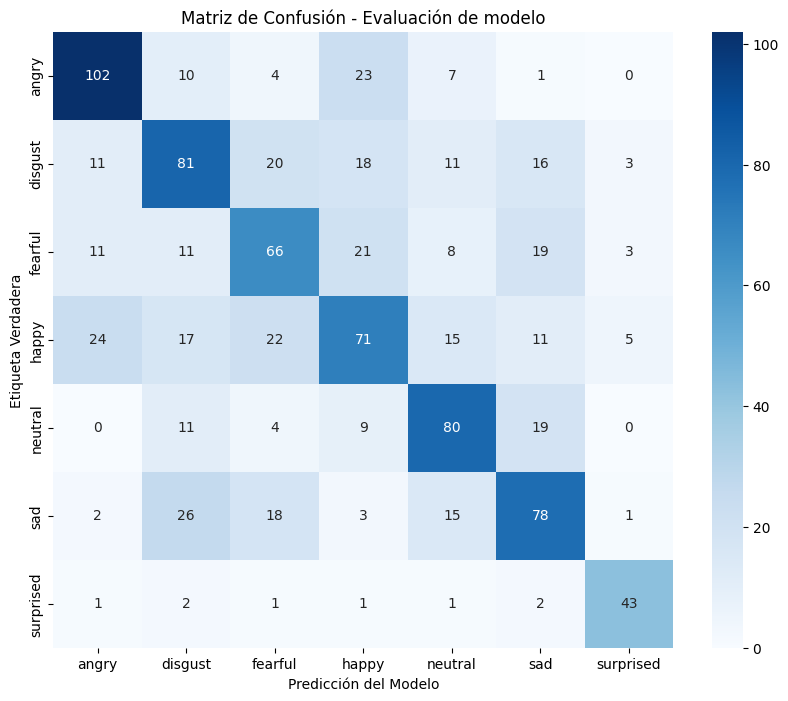

Matriz de confusion plana: 
 [[102  10   4  23   7   1   0]
 [ 11  81  20  18  11  16   3]
 [ 11  11  66  21   8  19   3]
 [ 24  17  22  71  15  11   5]
 [  0  11   4   9  80  19   0]
 [  2  26  18   3  15  78   1]
 [  1   2   1   1   1   2  43]]


In [13]:

# Define la ruta específica que vas a evaluar ahora
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_mel_spec'
# Prints
print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")
#Llamado a la funcion evaluadora
evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)


In [ ]:
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_spec'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)

In [ ]:
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_mel_spec'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)

In [ ]:
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_delta'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)

In [ ]:
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_delta2'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)